In [ ]:
%pip install tensorflow opencv-python matplotlib

In [1]:
# Import standard dependencies
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import tensorflow dependencies - Functional API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

2026-03-06 23:59:41.675729: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 23:59:41.709713: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 23:59:42.515318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
# Setup paths
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [ ]:
# Make the directories
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

In [ ]:
# Move LFW Images to the following repository data/negative
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

In [5]:
# Import uuid library to generate unique image names
import uuid

In [ ]:
# Establish a connection to the webcam
cap = cv2.VideoCapture(0)
while cap.isOpened(): 
    ret, frame = cap.read()
   
    # Cut down frame to 250x250px
    frame = frame[120:120+250,200:200+250, :]
    frame = cv2.flip(frame, flipCode = 1)
    
    # Collect anchors 
    if cv2.waitKey(1) & 0XFF == ord('a'):
        # Create the unique file path 
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out anchor image
        cv2.imwrite(imgname, frame)
    
    # Collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        # Create the unique file path 
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        # Write out positive image
        cv2.imwrite(imgname, frame)
    
    # Show image back to screen
    cv2.imshow('Image Collection', frame)
    
    # Breaking gracefully
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break
        
# Release the webcam
cap.release()
# Close the image show frame
cv2.destroyAllWindows()

In [6]:
anchor = tf.data.Dataset.list_files(ANC_PATH + '/*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH + '/*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH + '/*.jpg').take(300)

I0000 00:00:1772821793.004846   21545 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4172 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [7]:
def preprocess(file_path):
    # Read in image from file path
    byte_img = tf.io.read_file(file_path)
    # Load in the image
    img = tf.io.decode_jpeg(byte_img)

    # Preprocessing steps - resizing the image to be 100X100X3
    img = tf.image.resize(img, (100, 100))
    # Scale Image
    img = img / 255.0
    
    return img

In [8]:
# (anchor, positive) => 1,1,1,1
# (anchor, negative) => 0,0,0,0
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [9]:
samples = data.as_numpy_iterator()

In [10]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [11]:
res = preprocess_twin(*samples.next())

In [12]:
len(res)

3

In [13]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size = 1024)

In [14]:
# Train partition
train_data = data.take(round(len(data) * .7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [15]:
# Test partition
test_data = data.skip(round(len(data) * .7))
test_data = test_data.take(round(len(data) * .3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [16]:
# Building Embedding Layer
def make_embedding():
    inp = Input(shape=(100,100,3), name="input_image")
    
    # first block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

    # second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

    # third block
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

    # final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [17]:
embedding = make_embedding()
embedding.summary()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 17, 17, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs) # Preserves the layer name and properties!
       
    def call(self, inputs):
        # inputs is a single list containing your two embeddings
        
        # We unpack it and handle potential "nested" lists Keras sometimes creates
        input_embedding = inputs[0][0] if isinstance(inputs[0], list) else inputs[0]
        validation_embedding = inputs[1][0] if isinstance(inputs[1], list) else inputs[1]
        
        return tf.math.abs(input_embedding - validation_embedding)

In [19]:
# Make Siamese Model
def make_siamese_model():

    # Anchor image input in the network
    input_image = Input(name='input_img', shape=(100,100,3))

    # Validation image in the network
    validation_image = Input(name='validation_img', shape=(100,100,3))

    # combine siamese distance components
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer([embedding(input_image), embedding(validation_image)])

    # Classification Layer
    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name="SiameseNetwork")


In [20]:
siamese_network = make_siamese_model()
siamese_network.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ l1_dist[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [22]:
opt = tf.keras.optimizers.Adam(1e-4) # 0.0001

In [23]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_network)

In [25]:
@tf.function
def train_step(batch):
    
    # Record all of our operations 
    with tf.GradientTape() as tape:     
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_network(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_network.trainable_variables)
    
    # Calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_network.trainable_variables))
    
    # Return loss
    return loss

In [26]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            train_step(batch)
            progbar.update(idx+1)
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)

In [27]:
EPOCHS = 50
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)


2026-03-07 00:01:39.215513: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/stepTensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step

 Epoch 2/50
 1/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

2026-03-07 00:01:46.635285: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step

 Epoch 3/50
 1/27 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step

...

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step

 Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step

 Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step

 Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step

 Epoch 13/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step

 Epoch 14/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step

 Epoch 15/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step

 Epoch 16/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step

 Epoch 17/50
 1/27 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step

2026-03-07 00:03:08.330471: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 18/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 19/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 20/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 21/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 22/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 23/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 24/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 25/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 26/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 27/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 28/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 29/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 30/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 31/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 32/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 33/50
 1/27 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step

2026-03-07 00:04:34.773069: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 34/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 35/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 36/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 37/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 38/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 39/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 40/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 41/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 42/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 43/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 44/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 45/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step

 Epoch 46/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 47/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 48/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 49/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

 Epoch 50/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step


In [28]:
# Import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [29]:
# Get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [30]:
# Make predictions
y_hat = siamese_network.predict([test_input, test_val])
y_hat

2026-03-07 00:06:12.217974: I external/local_xla/xla/service/service.cc:163] XLA service 0x76aa480ef300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-07 00:06:12.217992: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-03-07 00:06:12.245565: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1772822173.614518   21624 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


array([[1.0000000e+00],
       [6.0151351e-08],
       [9.9888617e-01],
       [9.9999988e-01],
       [7.3303070e-08],
       [9.9907041e-01],
       [9.9999964e-01],
       [1.9518420e-05],
       [9.9764234e-01],
       [9.9999845e-01],
       [9.9999952e-01],
       [9.9995935e-01],
       [1.2125088e-08],
       [6.9828340e-05],
       [2.9523366e-09],
       [9.9782509e-01]], dtype=float32)

In [39]:
y_hat[y_hat > 0.5]

array([1.        , 0.99888617, 0.9999999 , 0.9990704 , 0.99999964,
       0.99764234, 0.99999845, 0.9999995 , 0.99995935, 0.9978251 ],
      dtype=float32)

In [31]:
# Creating a metric object 
m = Recall()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

np.float32(1.0)

In [32]:
# Creating a metric object 
m = Precision()

# Calculating the recall value 
m.update_state(y_true, y_hat)

# Return Recall Result
m.result().numpy()

np.float32(1.0)

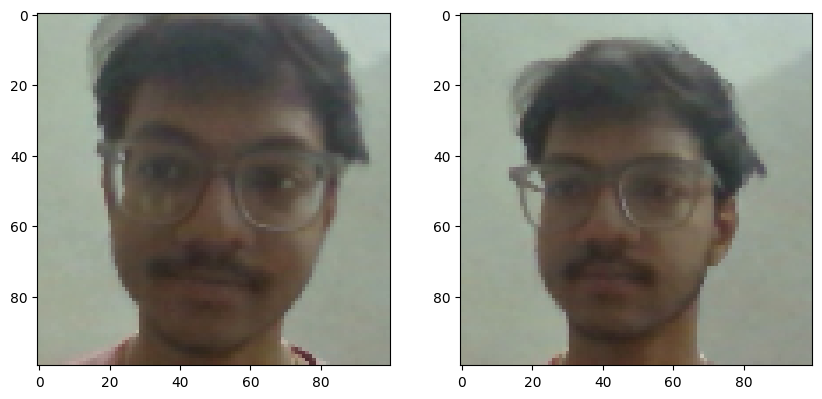

In [33]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[0])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[0])

# Renders cleanly
plt.show()

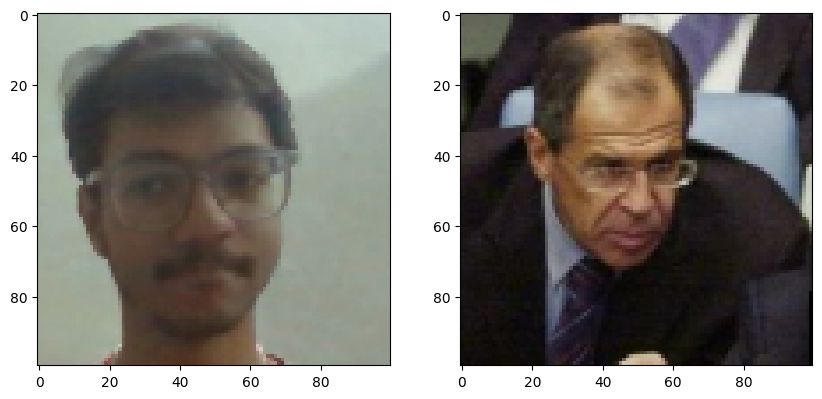

In [38]:
# Set plot size 
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[1])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[1])

# Renders cleanly
plt.show()

In [34]:
# Save weights
siamese_network.save('siamesemodel.h5')

In [35]:
# Reload model 
model = tf.keras.models.load_model('siamesemodel.h5', 
                                   custom_objects={'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

In [36]:
# Make predictions with reloaded model
model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step


array([[1.0000000e+00],
       [6.0151351e-08],
       [9.9888617e-01],
       [9.9999988e-01],
       [7.3303070e-08],
       [9.9907041e-01],
       [9.9999964e-01],
       [1.9518420e-05],
       [9.9764234e-01],
       [9.9999845e-01],
       [9.9999952e-01],
       [9.9995935e-01],
       [1.2125088e-08],
       [6.9828340e-05],
       [2.9523366e-09],
       [9.9782509e-01]], dtype=float32)

In [37]:
# View model summary
model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ l1_dist[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)